In [3]:
import numpy as np
import pandas as pd

season_links = {
    "21-22": "https://football-data.co.uk/mmz4281/2122/E0.csv",
    "22-23": "https://football-data.co.uk/mmz4281/2223/E0.csv",
    "23-24": "https://football-data.co.uk/mmz4281/2324/E0.csv",
}

# preview one season to check the link works
df = pd.read_csv(season_links["21-22"], encoding="latin-1")
print(df.shape)
df.head()

(380, 106)


,ï»¿Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,0,...,1.62,0.50,1.75,2.05,1.81,2.13,2.05,2.17,1.80,2.09
1,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,0,...,2.25,-1.00,2.05,1.75,2.17,1.77,2.19,1.93,2.10,1.79
2,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,0,...,1.62,0.25,1.79,2.15,1.81,2.14,1.82,2.19,1.79,2.12
3,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,0,...,1.94,-1.50,2.05,1.75,2.12,1.81,2.16,1.93,2.06,1.82
4,E0,14/08/2021,15:00,Everton,Southampton,3,1,H,0,1,...,1.67,-0.50,2.05,1.88,2.05,1.88,2.08,1.90,2.03,1.86


Firstly, we imported the raw data for a single season (2021-22) into Python to clean and process. Once cleaned and processed, we realised it is better to create a dictionary for all three seasons. This allows us to compute the Brier score individually and also across the seasons.

In [4]:
keep = ["FTR",
        "B365H", "B365D", "B365A",
        "BWH", "BWD", "BWA",
        "PSH", "PSD", "PSA",
        "WHH", "WHD", "WHA",
        "VCH", "VCD", "VCA"]

# 1. load and clean each season separately
season_dfs = {}
for season, link in season_links.items():
    d = pd.read_csv(link, encoding="latin-1")
    
# Removing rows with missing values
    missing = [c for c in keep if c not in d.columns]
    if missing:
        print(f"{season}: columns not found: {missing}")

    d = d[[c for c in keep if c in d.columns]].copy()
    rows_before = len(d)
    d = d.dropna().reset_index(drop=True)
    print(f"{season}: {rows_before} rows loaded, {len(d)} after dropping missing values")
    season_dfs[season] = d

21-22: 380 rows loaded, 380 after dropping missing values
22-23: 380 rows loaded, 380 after dropping missing values
23-24: 380 rows loaded, 378 after dropping missing values


For each season, we removed all the unneccessary columns and only kept the columns listed in 'keep'. With this new data, we identified cells with missing values and removed its entire row in order to keep the sample fair. From the output of this code, it is clear that the 2023-24 season had two missing values hence those two rows were removed. We now have a complete processed data set to work with.

In [5]:
# 2. Brier score functions
bookmakers = {"Bet365": "B365", "Bwin": "BW", "Pinnacle": "PS",
              "William Hill": "WH", "VC Bet": "VC"}

def odds_to_probs(odds):
    raw = 1 / odds
    return raw / raw.sum(axis=1, keepdims=True)

def brier(probs, outcomes):
    return ((probs - outcomes) ** 2).sum(axis=1)

The five bookmakers we want to compare are assigned their respective names and we carry on to convert the odds from bookmakers into raw probability in order to use the Brier score. We extracted the defintion of the Brier score function from [1] and turned it into applicable code for our dataset by altering Brier score code from [2].

In [6]:
# 3. score every bookmaker in every season
results = {}
for season, d in season_dfs.items():
    y = pd.get_dummies(d["FTR"]).reindex(columns=["H", "D", "A"], fill_value=0).to_numpy(dtype=float)
    results[season] = {}
    for name, p in bookmakers.items():
        odds = d[[f"{p}H", f"{p}D", f"{p}A"]].to_numpy(dtype=float)
        results[season][name] = brier(odds_to_probs(odds), y).mean()

By using the dictionary defined at the top, we are able to compute the Brier score for every bookmaker in every season and also produce a 3-season average for each bookmaker.

In [7]:
summary = pd.DataFrame(results)        # rows = bookmakers, columns = seasons

# 2. your averaging step
season_cols = list(season_dfs.keys())
summary["Average"] = summary[season_cols].mean(axis=1)
print(summary.sort_values("Average").round(4))

               21-22   22-23   23-24  Average
Pinnacle      0.5538  0.5740  0.5303   0.5527
VC Bet        0.5537  0.5740  0.5305   0.5527
Bet365        0.5540  0.5735  0.5309   0.5528
Bwin          0.5545  0.5731  0.5321   0.5532
William Hill  0.5542  0.5735  0.5323   0.5533


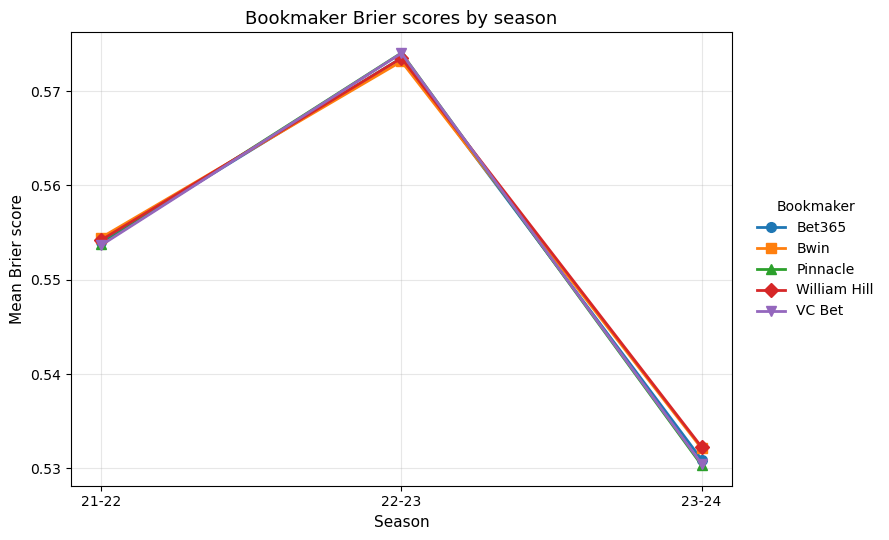

In [10]:
import matplotlib.pyplot as plt

season_cols = list(season_dfs.keys())     # only the season columns

markers = ["o", "s", "^", "D", "v"]

fig, ax = plt.subplots(figsize=(9, 5.5))

for name, m in zip(summary.index, markers):
    ax.plot(season_cols, summary.loc[name, season_cols],
            marker=m, markersize=7, linewidth=2, label=name)

ax.set_xlabel("Season", fontsize=11)
ax.set_ylabel("Mean Brier score", fontsize=11)
ax.set_title("Bookmaker Brier scores by season", fontsize=13)
ax.grid(alpha=0.3)
ax.legend(title="Bookmaker", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.tight_layout()
plt.show()

Created a visual output of the Brier scores for each bookmaker for each season by adpating the skeleton code found in [3]. 

[1]  Keskin, K. A game theory approach to football predictions. Public Choice 206, 241–261 (2026). https://doi.org/10.1007/s11127-025-01317-x 

[2]  https://github.com/PeterRochford/SkillMetrics/blob/master/skill_metrics/skill_score_brier.py

[3]  https://plotly.com/python/line-charts/#simple-line-plot